In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch 
import torch
import torch.nn as nn
from torchvision import transforms
import torch.nn.functional as F
from PIL import Image

In [84]:
#simple nn
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        return self.fc2(x)
    

In [51]:

# Load the checkpoint 
checkpoint = torch.load(
    "/home/poornima/A14IV/models/tabu_nn_20260302_093032.pt",
    map_location='cpu',
    weights_only=False
)



In [52]:
# model
model = SmallNet()
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Model loaded!")
print(f"Training info: {checkpoint['hyperparams']}")



Model loaded!
Training info: {'best_loss': 0.3161320686340332, 'iterations': 5000, 'architecture': 'SmallNet'}


In [85]:
# Check model architecture
print(" Model Architecture:")
print(model)



 Model Architecture:
SmallNet(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
# Check final layer
print("\n Final Layer Details")
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"{name}: in_features={module.in_features}, out_features={module.out_features}")



 Final Layer Details:
fc1: in_features=784, out_features=64
fc2: in_features=64, out_features=10


In [ ]:

# Check hyperparams if available
if 'hyperparams' in checkpoint:
    print(f"\nTraining hyperparams: {checkpoint['hyperparams']}")




Training hyperparams: {'best_loss': 0.3161320686340332, 'iterations': 5000, 'architecture': 'SmallNet'}


In [ ]:
# preprocess
transform = transforms.Compose([
    transforms.Grayscale(),              
    transforms.Resize((28, 28)),         
    transforms.ToTensor(),               
    transforms.Normalize((0.1307,), (0.3081,))  
])


In [ ]:

from torchvision import datasets
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
image, true_label = test_dataset[0]  # Get first test image
image = image.unsqueeze(0)  # Add batch dim [1, 1, 28, 28]
print(f"True label: {true_label}")

True label: 7


In [ ]:
#check the input shape 
print(f"Input shape: {image.shape}")  
assert image.shape == (1, 1, 28, 28), f"Wrong input shape: {image.shape}"


Input shape: torch.Size([1, 1, 28, 28])


In [ ]:
#Run inference 
with torch.no_grad():
    logits = model(image)  # Output 


In [57]:
# Get prediction 
probabilities = F.softmax(logits, dim=1)
confidence, predicted = torch.max(probabilities, dim=1)

pred_class = predicted[0].item()
conf = confidence[0].item() * 100


 Prediction: Digit 7
Confidence: 95.65%

 All probabilities:
  Digit 0: 0.10%
  Digit 1: 0.04%
  Digit 2: 0.09%
  Digit 3: 1.04%
  Digit 4: 0.11%
  Digit 5: 0.17%
  Digit 6: 0.02%
  Digit 7: 95.65% PREDICTED
  Digit 8: 0.15%
  Digit 9: 2.63%


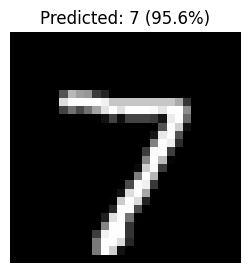

In [58]:
# print the results 
print(f"\n Prediction: Digit {pred_class}")
print(f"Confidence: {conf:.2f}%")

# Show all class probabilities
print(f"\n All probabilities:")
for digit in range(10):
    prob = probabilities[0][digit].item() * 100
    marker = " PREDICTED" if digit == pred_class else ""
    print(f"  Digit {digit}: {prob:.2f}%{marker}")

# Display the image
plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze().numpy(), cmap='gray')
plt.title(f"Predicted: {pred_class} ({conf:.1f}%)")
plt.axis('off')
plt.show()